# IMC Prosperity 4 — Comprehensive Trading Analysis Notebook v2
### Round-by-Round Strategy Development Playground

---

## What this notebook does

This notebook is a **complete algorithmic trading analysis toolkit** for IMC Prosperity.
Each section builds on the previous one, taking you from raw CSV data to a deployable trading algorithm.

**Data input → Analysis → Insight → Strategy → Algorithm → Backtest → Submit**

---

## Understanding the two input file types

| File | What it contains | Primary use |
|------|-----------------|-------------|
| `prices_round_X_day_Y.csv` | Full order book snapshot every 100 steps | Fair value, spread, volatility, strategy backtesting |
| `trades_round_X_day_Y.csv` | Every actual completed trade in the market | Bot behaviour, volume, price discovery |

### Why does `count` show 20,000 for each product?

Each price file has **10,000 timestamps** (steps 0, 100, 200 … 999,900) per day.
With 2 days (`day_-2` + `day_-1`) and 2 products, the combined DataFrame has
`2 days × 10,000 timestamps × 1 product per row = 20,000 rows per product`.
This is correct — the DataFrame is **long format** (one row per product per timestamp).

### Column glossary — prices file

| Column | Meaning | How to use |
|--------|---------|-----------|
| `day` | Simulation day (-2 = older training, -1 = recent) | Split analysis by day to check stability |
| `timestamp` | Step index 0–999,900 in 100-step increments | Time axis for all charts |
| `bid_price_1` | Best (highest) buy offer from bots | Upper bound of what you can sell at instantly |
| `bid_volume_1` | Units available at best bid | Maximum you can sell in one tick |
| `bid_price_2/3` | Second/third best bids (lower prices) | Book depth — how much you can sell before price drops |
| `ask_price_1` | Best (lowest) sell offer from bots | Lower bound of what you can buy at instantly |
| `ask_volume_1` | Units available at best ask | Maximum you can buy in one tick |
| `mid_price` | (bid_price_1 + ask_price_1) / 2 | Proxy for fair value |
| `profit_and_loss` | YOUR algo's cumulative P&L | Zero in training; non-zero after live submission |

### Column glossary — trades file

| Column | Meaning |
|--------|---------|
| `timestamp` | When the trade happened |
| `buyer` / `seller` | 'SUBMISSION' = your algo; blank = anonymous bot |
| `symbol` | Product name |
| `price` | Actual execution price |
| `quantity` | Units traded |

---
## 0. Setup & Configuration

> **Fix from v1:** `POSITION_LIMIT` is now a per-product dictionary.
> Different products have different limits in each round.
> The notebook auto-uses the correct limit for each product.

**How to use for future rounds:** Just update `PRICE_FILES`, `TRADE_FILES`, and `POSITION_LIMITS`.
All subsequent cells adapt automatically.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from collections import deque
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='darkgrid')

# ── CONFIGURE FOR EACH ROUND ──────────────────────────────────────────────
# Add/remove files as needed. Works with any number of days and products.
PRICE_FILES = [
    '../data/prices_round_2_day_-1.csv',
    '../data/prices_round_2_day_0.csv',
    '../data/prices_round_2_day_1.csv'
]
TRADE_FILES = [
    '../data/trades_round_2_day_-1.csv',
    '../data/trades_round_2_day_0.csv',
    '../data/trades_round_2_day_1.csv'
]

# Per-product position limits (from the round description).
# FIX from v1: was a single POSITION_LIMIT=80, now per-product dict.
# Any product NOT in this dict defaults to 80.
POSITION_LIMITS = {
    'ASH_COATED_OSMIUM': 80,
    'INTARIAN_PEPPER_ROOT': 80
}

def get_limit(product):
    return POSITION_LIMITS.get(product, 80)

print('Setup complete. Position limits:', POSITION_LIMITS)

Setup complete. Position limits: {'ASH_COATED_OSMIUM': 80, 'INTARIAN_PEPPER_ROOT': 80}


---
## 1. Load & Combine Data

We combine all price files into one long-format DataFrame and sort by global time.
`global_time` is a synthetic index that orders rows correctly across days:
`global_time = day_index × 1,000,000 + timestamp`

This ensures Day -1 timestamp 0 always comes after Day -2 timestamp 999900.

In [14]:
def load_prices(files):
    dfs = [pd.read_csv(f, sep=';') for f in files]
    df = pd.concat(dfs, ignore_index=True)
    day_rank = {d: i for i, d in enumerate(sorted(df['day'].unique()))}
    df['global_time'] = df['day'].map(day_rank) * 1_000_000 + df['timestamp']
    return df.sort_values('global_time').reset_index(drop=True)

def load_trades(files):
    dfs = [pd.read_csv(f, sep=';') for f in files]
    return pd.concat(dfs, ignore_index=True)

prices_df = load_prices(PRICE_FILES)
trades_df  = load_trades(TRADE_FILES)

products = prices_df['product'].unique().tolist()
n_products = len(products)
days = sorted(prices_df['day'].unique())

print(f'Products found : {products}')
print(f'Days           : {days}')
print(f'Price rows     : {len(prices_df):,}  (= {n_products} products × {len(days)} days × 10,000 timestamps each — this is CORRECT)')
print(f'Trade rows     : {len(trades_df):,}')
print()
print('Per-product row count:')
for p in products:
    n = len(prices_df[prices_df['product']==p])
    print(f'  {p}: {n:,} rows = {len(days)} days × {n // len(days):,} timestamps per day')
prices_df.head(3)

Products found : ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
Days           : [-1, 0, 1]
Price rows     : 60,000  (= 2 products × 3 days × 10,000 timestamps each — this is CORRECT)
Trade rows     : 2,391

Per-product row count:
  INTARIAN_PEPPER_ROOT: 30,000 rows = 3 days × 10,000 timestamps per day
  ASH_COATED_OSMIUM: 30,000 rows = 3 days × 10,000 timestamps per day


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_time
0,-1,0,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11009.0,25.0,NaN,NaN,NaN,NaN,11001.5,0.0,0
1,-1,0,ASH_COATED_OSMIUM,9982.0,21.0,NaN,NaN,NaN,NaN,10000.0,13.0,10003.0,21.0,NaN,NaN,9991.0,0.0,0
2,-1,100,ASH_COATED_OSMIUM,9984.0,15.0,NaN,NaN,NaN,NaN,10000.0,15.0,10003.0,26.0,NaN,NaN,9992.0,0.0,100


---
## 2. Basic Statistics — Price Summary

**What to look for:**
- `std` of mid_price: low = stable product (use fixed FV), high = volatile (use adaptive FV)
- `mean` of spread: your maximum passive profit per round-trip
- `min`/`max` of mid_price: sets the range for your strategy's price grid

In [15]:
summary_records = []
for product in products:
    pf = prices_df[prices_df['product'] == product]
    spread = pf['ask_price_1'] - pf['bid_price_1']
    rec = {
        'product': product,
        'mid_mean': pf['mid_price'].mean(),
        'mid_std': pf['mid_price'].std(),
        'mid_min': pf['mid_price'].min(),
        'mid_max': pf['mid_price'].max(),
        'spread_mean': spread.mean(),
        'spread_std': spread.std(),
        'spread_min': spread.min(),
        'spread_max': spread.max(),
        'pos_limit': get_limit(product),
    }
    summary_records.append(rec)
    print(f'\n══ {product} ══')
    print(pf[['mid_price','bid_price_1','ask_price_1']].describe().round(4))
    print(f'  Spread  mean={spread.mean():.2f}  std={spread.std():.2f}  min={spread.min():.1f}  max={spread.max():.1f}')
    print(f'  Position limit: {get_limit(product)}')

summary_df = pd.DataFrame(summary_records).set_index('product')


══ INTARIAN_PEPPER_ROOT ══
        mid_price  bid_price_1  ask_price_1
count  30000.0000   28866.0000   28811.0000
mean   12480.3326   12493.9003   12506.9579
std      996.6367     865.9515     865.9710
min        0.0000   10992.0000   10999.0000
25%    11746.0000   11743.0000   11757.0000
50%    12497.5000   12494.0000   12507.0000
75%    13249.1250   13244.0000   13258.0000
max    14003.0000   13999.0000   14010.0000
  Spread  mean=14.12  std=2.79  min=2.0  max=22.0
  Position limit: 80

══ ASH_COATED_OSMIUM ══
        mid_price  bid_price_1  ask_price_1
count  30000.0000   28804.0000   28851.0000
mean    9983.2112    9992.7453   10008.9753
std      420.0208       4.7178       4.8018
min        0.0000    9976.0000    9985.0000
25%     9998.0000    9990.0000   10006.0000
50%    10001.0000    9993.0000   10009.0000
75%    10004.0000    9996.0000   10012.0000
max    10023.0000   10016.0000   10025.0000
  Spread  mean=16.23  std=2.52  min=5.0  max=22.0
  Position limit: 80


---
## 3. Mid-Price Time Series

**How to read this chart:**
- Blue line = actual mid price (tick by tick)
- Red line = 200-step rolling mean (the trend / slow-moving fair value)
- Shaded band = bid-ask band (you profit by being inside this, quoting tighter than the bots)

**What patterns to look for:**
- Flat red line → product mean-reverts → market making works perfectly
- Drifting red line → price trends → you need an adaptive fair value (EMA)
- Day boundary (yellow shading) → check if price jumps between days

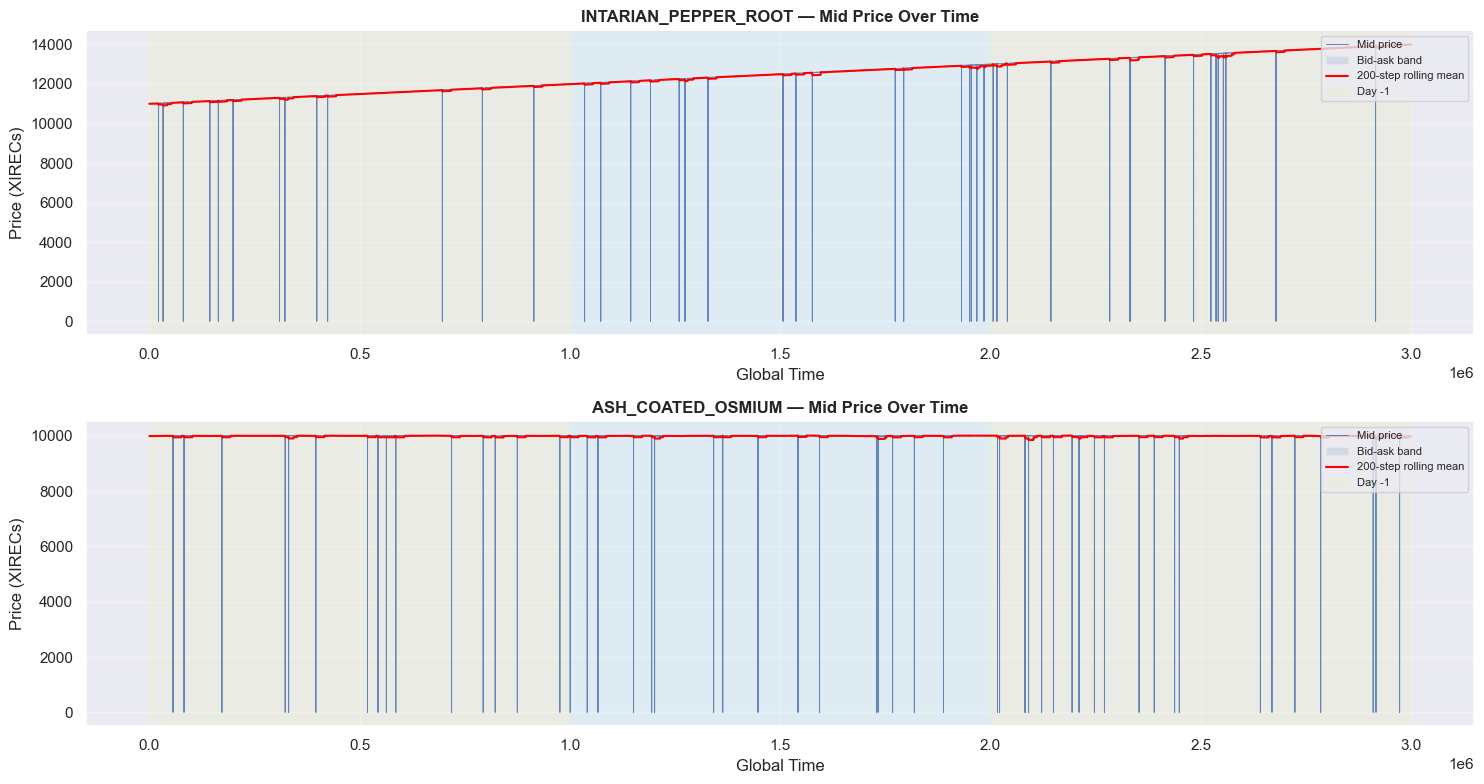

In [16]:
fig, axes = plt.subplots(n_products, 1, figsize=(15, 4*n_products))
if n_products == 1: axes = [axes]
for ax, product in zip(axes, products):
    pf = prices_df[prices_df['product']==product]
    ax.plot(pf['global_time'], pf['mid_price'], lw=0.7, label='Mid price', alpha=0.85)
    ax.fill_between(pf['global_time'], pf['bid_price_1'], pf['ask_price_1'], alpha=0.15, label='Bid-ask band')
    ax.plot(pf['global_time'], pf['mid_price'].rolling(200, min_periods=1).mean(),
            color='red', lw=1.5, label='200-step rolling mean')
    for i, day in enumerate(days):
        d = pf[pf['day']==day]
        ax.axvspan(d['global_time'].min(), d['global_time'].max(),
                   alpha=0.05, color=['yellow','cyan'][i%2], label=f'Day {day}' if i==0 else '')
    ax.set_title(f'{product} — Mid Price Over Time', fontweight='bold')
    ax.set_xlabel('Global Time'); ax.set_ylabel('Price (XIRECs)')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

---
## 4. Price Distribution & Normality

**Why it matters:** A normal distribution around a fixed mean is the signature of a
mean-reverting product — ideal for market making. A flat or multi-modal distribution
suggests trending or regime-switching behaviour.

**Shapiro-Wilk test:** Tests if the data is drawn from a normal distribution.
- p > 0.05 → can't reject normality (consistent with normal)
- p < 0.05 → data is NOT normally distributed

**Note:** Even non-normal products can support market making if the spread is consistent.
Normality tells you about the FV stability, not about whether trading is possible.

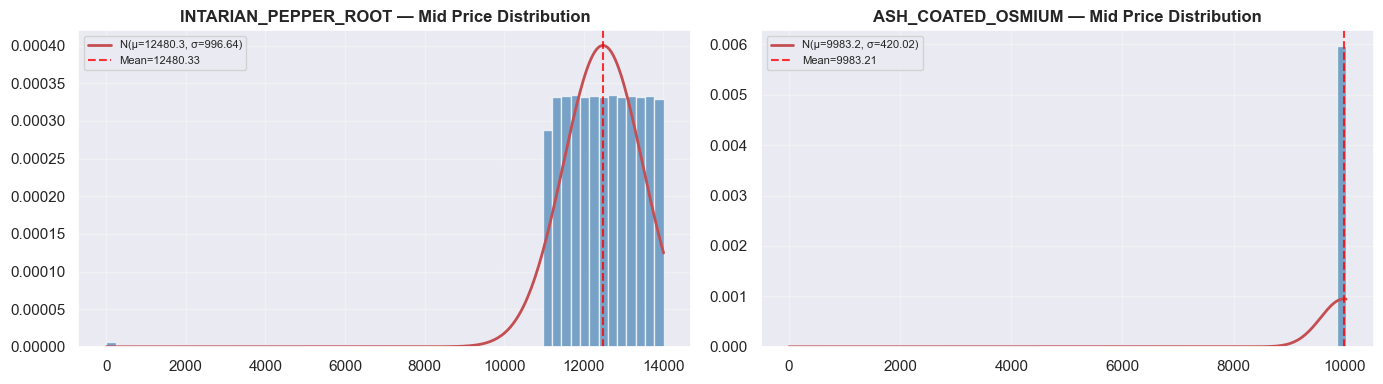

Shapiro-Wilk Normality Test (sample of 5000):
  INTARIAN_PEPPER_ROOT: W=0.8178, p=7.72e-60 → NOT NORMAL
    Interpretation: Use adaptive FV (EMA)
  ASH_COATED_OSMIUM: W=0.0219, p=2.49e-95 → NOT NORMAL
    Interpretation: Use adaptive FV (EMA)


In [17]:
fig, axes = plt.subplots(1, n_products, figsize=(7*n_products, 4))
if n_products == 1: axes = [axes]
for ax, product in zip(axes, products):
    pf = prices_df[prices_df['product']==product]['mid_price'].dropna()
    mu, sigma = pf.mean(), pf.std()
    ax.hist(pf, bins=60, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    x = np.linspace(pf.min(), pf.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'N(μ={mu:.1f}, σ={sigma:.2f})')
    ax.axvline(mu, color='red', linestyle='--', alpha=0.8, label=f'Mean={mu:.2f}')
    ax.set_title(f'{product} — Mid Price Distribution', fontweight='bold')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('Shapiro-Wilk Normality Test (sample of 5000):')
for product in products:
    pf = prices_df[prices_df['product']==product]['mid_price'].dropna()
    s = pf.sample(min(5000, len(pf)), random_state=42)
    stat, p = stats.shapiro(s)
    verdict = 'NORMAL (consistent)' if p > 0.05 else 'NOT NORMAL'
    print(f'  {product}: W={stat:.4f}, p={p:.2e} → {verdict}')
    print(f'    Interpretation: {"Fixed FV reliable" if p > 0.05 else "Use adaptive FV (EMA)"}')

---
## 5. Bid-Ask Spread Analysis

**The spread is your business model.** As a market maker, you quote INSIDE the existing
spread. The bot spreads set the ceiling on your profit margin.

- `spread_mean / 2` = theoretical max profit per unit per round-trip
- Consistent spread → predictable income; volatile spread → your quotes may become stale
- Occasional narrow spreads (dips) → competition from other market makers

**Decision rule:** If your passive quote is tighter than `(fv ± spread/2)`, bots will
trade with you. If wider, they'll ignore you. If you go inside fv, you'll lose money.

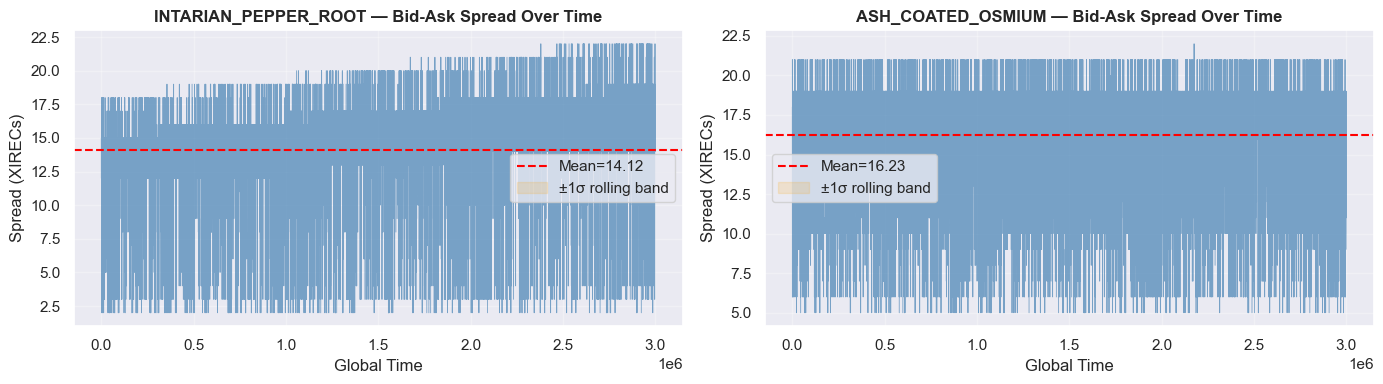

Spread distribution percentiles:
  INTARIAN_PEPPER_ROOT: p10=12.0 p25=13.0 p50=14.0 p75=15.0 p90=17.0
    Max passive profit/unit: 7.06 XIRECs
  ASH_COATED_OSMIUM: p10=16.0 p25=16.0 p50=16.0 p75=18.0 p90=19.0
    Max passive profit/unit: 8.12 XIRECs


In [18]:
fig, axes = plt.subplots(1, n_products, figsize=(7*n_products, 4))
if n_products == 1: axes = [axes]
for ax, product in zip(axes, products):
    pf = prices_df[prices_df['product']==product].copy()
    pf['spread'] = pf['ask_price_1'] - pf['bid_price_1']
    ax.plot(pf['global_time'], pf['spread'], lw=0.6, alpha=0.7, color='steelblue')
    ax.axhline(pf['spread'].mean(), color='red', ls='--', label=f'Mean={pf["spread"].mean():.2f}')
    ax.fill_between(pf['global_time'],
                    pf['spread'].rolling(200).mean() - pf['spread'].rolling(200).std(),
                    pf['spread'].rolling(200).mean() + pf['spread'].rolling(200).std(),
                    alpha=0.15, color='orange', label='±1σ rolling band')
    ax.set_title(f'{product} — Bid-Ask Spread Over Time', fontweight='bold')
    ax.set_xlabel('Global Time'); ax.set_ylabel('Spread (XIRECs)')
    ax.legend()
plt.tight_layout(); plt.show()

print('Spread distribution percentiles:')
for product in products:
    pf = prices_df[prices_df['product'] == product]
    s = pf['ask_price_1'] - pf['bid_price_1']
    print(f'  {product}: p10={s.quantile(0.1):.1f} p25={s.quantile(0.25):.1f} '
          f'p50={s.quantile(0.5):.1f} p75={s.quantile(0.75):.1f} p90={s.quantile(0.9):.1f}')
    print(f'    Max passive profit/unit: {s.mean()/2:.2f} XIRECs')

---
## 6. Order Book Depth & Microstructure

The order book has 3 price levels on each side. This section analyses:
- **Total depth**: how much volume you can trade before the price moves
- **Order Book Imbalance (OBI)**: a real-time directional signal
- **Volume-Weighted Mid (Wall Mid)**: a better fair value than arithmetic mid

**Order Book Imbalance (OBI):**
```
OBI = (bid_volume - ask_volume) / (bid_volume + ask_volume)  ∈ [-1, +1]
```
OBI > 0 → more buy pressure → price likely to rise (short-term)
OBI < 0 → more sell pressure → price likely to fall (short-term)
This is the most widely-used microstructure signal in HFT.

**Volume-Weighted Mid (Wall Mid):**
```
VWM = (ask_price_1 × bid_vol_1 + bid_price_1 × ask_vol_1) / (bid_vol_1 + ask_vol_1)
```
This weights the mid towards the THINNER side of the book, which is a better estimate
of fair value than the arithmetic mid.


══ INTARIAN_PEPPER_ROOT — Order Book Depth ══
  BID: bid_volume_1: avg=11.6 max=25  |  bid_volume_2: avg=19.8 max=25  |  bid_volume_3: avg=20.0 max=25
  ASK: ask_volume_1: avg=11.6 max=25  |  ask_volume_2: avg=19.8 max=25  |  ask_volume_3: avg=20.0 max=25
  Total avg book depth: Bid=24.2  Ask=24.1
  Limit/48 = 166% of book depth

══ ASH_COATED_OSMIUM — Order Book Depth ══
  BID: bid_volume_1: avg=14.2 max=30  |  bid_volume_2: avg=24.5 max=30  |  bid_volume_3: avg=24.8 max=30
  ASK: ask_volume_1: avg=14.2 max=30  |  ask_volume_2: avg=24.4 max=30  |  ask_volume_3: avg=25.0 max=30
  Total avg book depth: Bid=30.2  Ask=30.3
  Limit/60 = 132% of book depth

── Order Book Imbalance (OBI) Analysis ──
  INTARIAN_PEPPER_ROOT: OBI→next-tick return correlation = nan
    OBI has weak predictive power
  ASH_COATED_OSMIUM: OBI→next-tick return correlation = nan
    OBI has weak predictive power


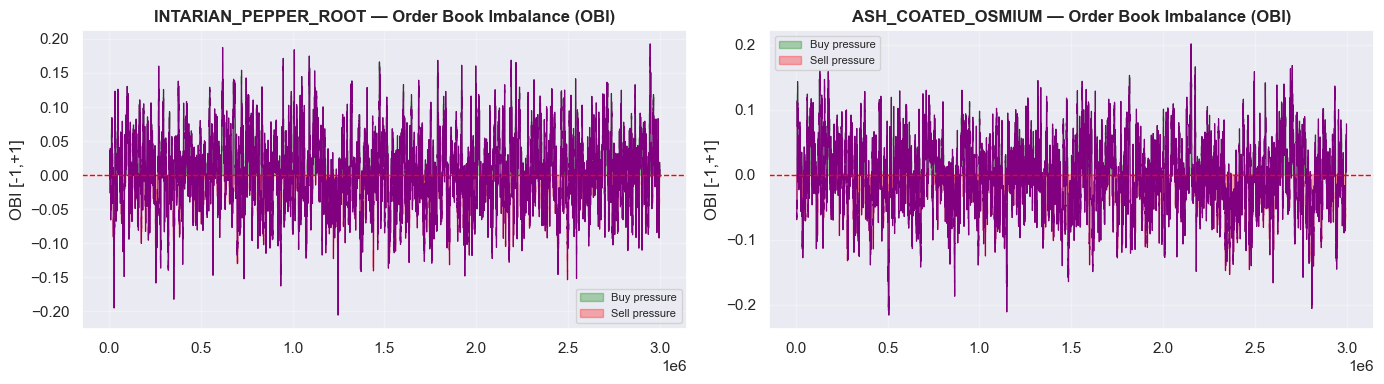

In [19]:
for product in products:
    pf = prices_df[prices_df['product']==product].copy()
    print(f'\n══ {product} — Order Book Depth ══')
    for side, cols in [('BID',['bid_volume_1','bid_volume_2','bid_volume_3']),
                       ('ASK',['ask_volume_1','ask_volume_2','ask_volume_3'])]:
        existing = [c for c in cols if c in pf.columns and pf[c].notna().any()]
        if existing:
            parts = [f'{c}: avg={pf[c].mean():.1f} max={pf[c].max():.0f}' for c in existing]
            print(f'  {side}: ' + '  |  '.join(parts))
    bid_depth = sum(pf[c].fillna(0).mean() for c in ['bid_volume_1','bid_volume_2','bid_volume_3'] if c in pf)
    ask_depth = sum(pf[c].fillna(0).mean() for c in ['ask_volume_1','ask_volume_2','ask_volume_3'] if c in pf)
    print(f'  Total avg book depth: Bid={bid_depth:.1f}  Ask={ask_depth:.1f}')
    print(f'  Limit/{bid_depth+ask_depth:.0f} = {get_limit(product)/(bid_depth+ask_depth)*100:.0f}% of book depth')

# ── ORDER BOOK IMBALANCE ─────────────────────────────────────────
print('\n── Order Book Imbalance (OBI) Analysis ──')
obi_fig, obi_axes = plt.subplots(1, n_products, figsize=(7*n_products, 4))
if n_products == 1: obi_axes = [obi_axes]

for ax, product in zip(obi_axes, products):
    pf = prices_df[prices_df['product']==product].copy()
    bid_vol = pf[['bid_volume_1','bid_volume_2','bid_volume_3']].fillna(0).sum(axis=1)
    ask_vol = pf[['ask_volume_1','ask_volume_2','ask_volume_3']].fillna(0).sum(axis=1)
    pf['obi'] = (bid_vol - ask_vol) / (bid_vol + ask_vol + 1e-9)
    ax.plot(pf['global_time'], pf['obi'].rolling(50).mean(), lw=0.8, color='purple')
    ax.axhline(0, color='red', lw=1, ls='--')
    ax.fill_between(pf['global_time'], 0, pf['obi'].rolling(50).mean(),
                    where=pf['obi'].rolling(50).mean()>0, alpha=0.3, color='green', label='Buy pressure')
    ax.fill_between(pf['global_time'], 0, pf['obi'].rolling(50).mean(),
                    where=pf['obi'].rolling(50).mean()<0, alpha=0.3, color='red', label='Sell pressure')
    ax.set_title(f'{product} — Order Book Imbalance (OBI)', fontweight='bold')
    ax.set_ylabel('OBI [-1,+1]'); ax.legend(fontsize=8)
    # Predictive power: does OBI predict next-tick return?
    future_ret = pf['mid_price'].pct_change().shift(-1)
    corr = pf['obi'].corr(future_ret)
    print(f'  {product}: OBI→next-tick return correlation = {corr:.4f}')
    print(f'    {"OBI has PREDICTIVE power" if abs(corr) > 0.05 else "OBI has weak predictive power"}')
plt.tight_layout(); plt.show()

---
## 7. Return & Volatility Analysis

**Tick returns** = `(mid[t] - mid[t-1]) / mid[t-1]`

**Why volatility matters for your strategy:**
- High volatility → your passive quotes go stale faster (price moves away from your quote price)
- High volatility → widen your edge to avoid adverse selection
- Low volatility → can quote very tightly with small edge

**Adverse selection** is when you quote a bid at 100 and a bot fills it — but the reason
they're selling is because the true price just dropped to 90. You bought at 100, price is 90.
Wider edge = more protection against this, at the cost of fewer fills.

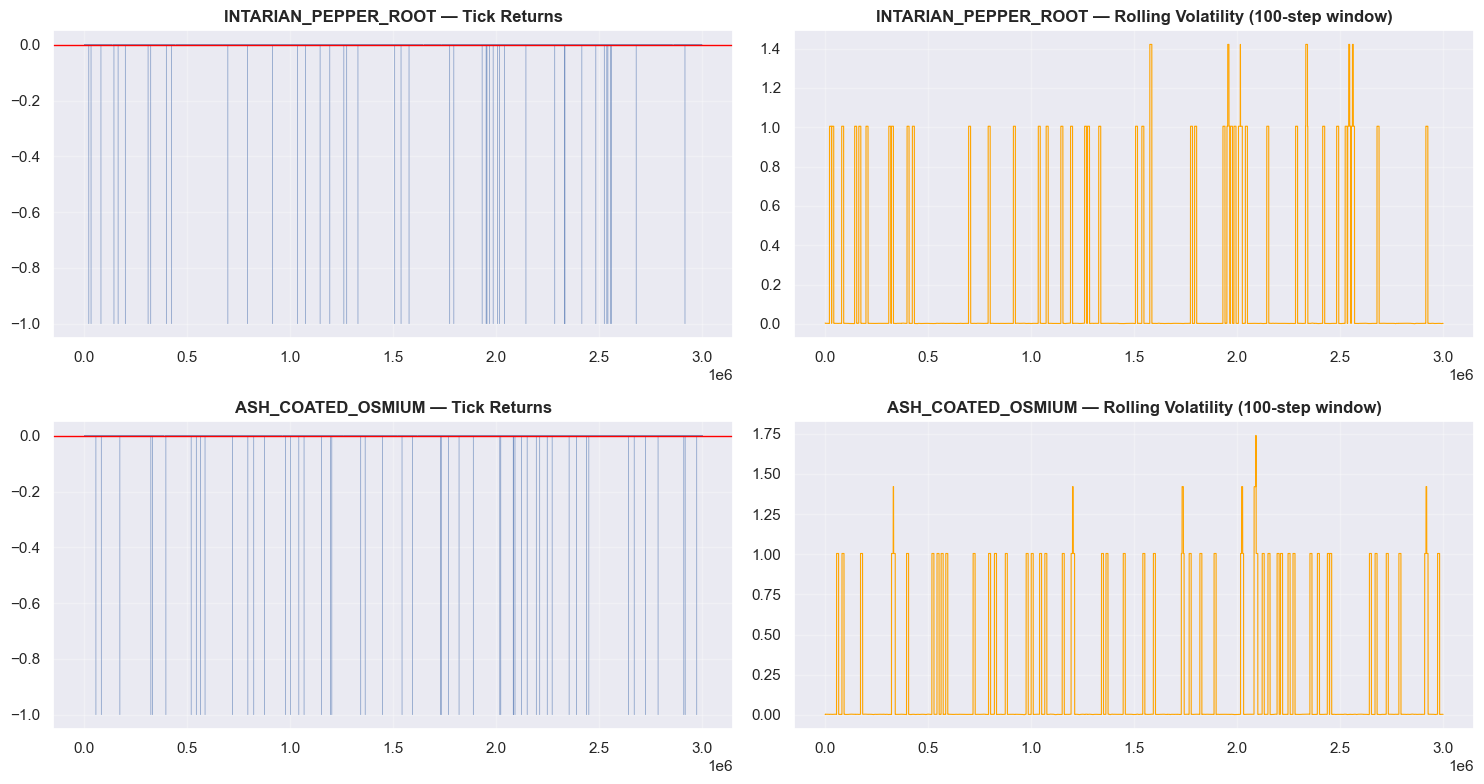

Return statistics:
  INTARIAN_PEPPER_ROOT: mean=inf%  std=nan%  skew=nan  kurt=nan
    Annual vol proxy (x sqrt(10000*252)): nan%
  ASH_COATED_OSMIUM: mean=inf%  std=nan%  skew=nan  kurt=nan
    Annual vol proxy (x sqrt(10000*252)): nan%


In [20]:
fig, axes = plt.subplots(n_products, 2, figsize=(15, 4*n_products))
if n_products == 1: axes = axes.reshape(1,-1)
for row, product in enumerate(products):
    pf = prices_df[prices_df['product']==product].copy()
    pf['ret'] = pf['mid_price'].pct_change()
    roll_vol = pf['ret'].rolling(100, min_periods=10).std()*np.sqrt(100)
    axes[row,0].plot(pf['global_time'], pf['ret'], lw=0.5, alpha=0.7)
    axes[row,0].axhline(0, color='red', lw=1)
    axes[row,0].set_title(f'{product} — Tick Returns', fontweight='bold')
    axes[row,1].plot(pf['global_time'], roll_vol, color='orange', lw=0.8)
    axes[row,1].set_title(f'{product} — Rolling Volatility (100-step window)', fontweight='bold')
plt.tight_layout(); plt.show()

print('Return statistics:')
for product in products:
    pf = prices_df[prices_df['product']==product]
    rets = pf['mid_price'].pct_change().dropna()
    print(f'  {product}: mean={rets.mean()*100:.5f}%  std={rets.std()*100:.5f}%  skew={stats.skew(rets):.3f}  kurt={stats.kurtosis(rets):.3f}')
    print(f'    Annual vol proxy (x sqrt(10000*252)): {rets.std()*np.sqrt(10000*252)*100:.1f}%')

---
## 8. Stationarity Tests (ADF & Hurst Exponent)

**Augmented Dickey-Fuller (ADF):**
Tests whether the price series has a 'unit root' (non-stationary = trending) or is
stationary (mean-reverting).
- p < 0.05 → stationary → **use fixed FV, market making ideal**
- p ≥ 0.05 → non-stationary → **use adaptive FV, consider trend following**

**Hurst Exponent (H):**
Measures the long-range memory of a time series.
- H < 0.5 → mean-reverting (anti-persistent) → market making
- H ≈ 0.5 → random walk → no edge from price history alone
- H > 0.5 → trending (persistent) → momentum/trend following

**Half-life of mean reversion:**
How many ticks before price is expected to revert halfway to the mean.
Formula: fit OLS on Δprice = α + β×price(t-1). Half-life = -ln(2)/β
Short half-life = fast reversion = very tight quotes viable.

In [21]:
def adf_test(series, name):
    try:
        from statsmodels.tsa.stattools import adfuller
        r = adfuller(series.dropna().values, maxlag=20, autolag='AIC')
        p = r[1]
        print(f'  {name}: ADF={r[0]:.4f}  p={p:.2e}  → {"STATIONARY" if p<0.05 else "NON-STATIONARY"}')
        return p
    except ImportError:
        # Manual alternative: OLS half-life
        y = series.diff().dropna().values
        x = series.shift(1).dropna().values
        beta = np.cov(x,y)[0,1] / np.var(x)
        if beta < 0:
            hl = -np.log(2)/beta
            print(f'  {name}: half-life≈{hl:.1f} ticks → {"fast mean reversion" if hl<100 else "slow mean reversion"}')
        else:
            print(f'  {name}: NO mean reversion detected')
        return None

def hurst_exponent(ts, max_lag=100):
    """Compute Hurst exponent via rescaled range analysis."""
    lags = range(2, max_lag)
    tau = [np.std(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
    reg = np.polyfit(np.log(lags), np.log(tau), 1)
    return reg[0]  # Hurst exponent

def mean_reversion_halflife(series):
    """OLS estimate of mean-reversion half-life in ticks."""
    y = series.diff().dropna().values
    x = series.shift(1).dropna().values
    beta = np.cov(x,y)[0,1] / (np.var(x) + 1e-12)
    return -np.log(2)/beta if beta < 0 else np.inf

print('══ Stationarity Analysis ══\n')
for product in products:
    pf = prices_df[prices_df['product']==product]['mid_price'].dropna()
    print(f'{product}:')
    adf_test(pf, 'Mid Price')
    H = hurst_exponent(pf.values)
    hl = mean_reversion_halflife(pf)
    regime = 'MEAN-REVERTING' if H < 0.45 else ('TRENDING' if H > 0.55 else 'RANDOM WALK')
    print(f'    Hurst H={H:.3f} → {regime}')
    print(f'    Mean-reversion half-life ≈ {hl:.1f} ticks')
    if hl < 50:
        print(f'    → Very fast reversion: tight quotes (edge=1-3) viable')
    elif hl < 500:
        print(f'    → Moderate reversion: medium quotes (edge=3-6) suggested')
    else:
        print(f'    → Slow/no reversion: use EMA-adaptive FV')
    print()

══ Stationarity Analysis ══

INTARIAN_PEPPER_ROOT:
  Mid Price: ADF=-4.6279  p=1.15e-04  → STATIONARY
    Hurst H=0.001 → MEAN-REVERTING
    Mean-reversion half-life ≈ 2.8 ticks
    → Very fast reversion: tight quotes (edge=1-3) viable

ASH_COATED_OSMIUM:
  Mid Price: ADF=-76.3757  p=0.00e+00  → STATIONARY
    Hurst H=0.000 → MEAN-REVERTING
    Mean-reversion half-life ≈ 0.7 ticks
    → Very fast reversion: tight quotes (edge=1-3) viable



---
## 9. Market Trades Analysis & Trader ID Signals

The trades file shows every transaction that happened. Unlike the order book (what bots
OFFERED to do), trades show what they ACTUALLY did.

**Key insights to extract:**
- Trade price distribution → where does execution actually happen?
- Volume distribution → how much do bots trade at once?
- Trade frequency → how liquid is this product?
- **Trader ID analysis** → some bots are 'informed' (they front-run price moves)

**Trader ID Front-Running (used in P2 R5, P3 R5):**
If a specific bot consistently buys BEFORE a price rise, you can mirror their trades.
Compute: for each trader_id, what is the average price change in the next K ticks
after they buy? If consistently positive → front-run them.

Market Trade Summary:
                       price                                               \
                       count      mean     std      min      25%      50%   
symbol                                                                      
ASH_COATED_OSMIUM     1395.0  10000.65    9.35   9979.0   9993.0  10000.0   
INTARIAN_PEPPER_ROOT   996.0  12535.99  860.45  10996.0  11787.0  12560.5   

                                        quantity                             \
                           75%      max    count  mean   std  min  25%  50%   
symbol                                                                        
ASH_COATED_OSMIUM     10009.00  10020.0   1395.0  5.11  2.24  2.0  3.0  5.0   
INTARIAN_PEPPER_ROOT  13289.75  13999.0    996.0  5.05  1.54  3.0  4.0  5.0   

                                 
                      75%   max  
symbol                           
ASH_COATED_OSMIUM     6.0  10.0  
INTARIAN_PEPPER_ROOT  6.0   8.0  


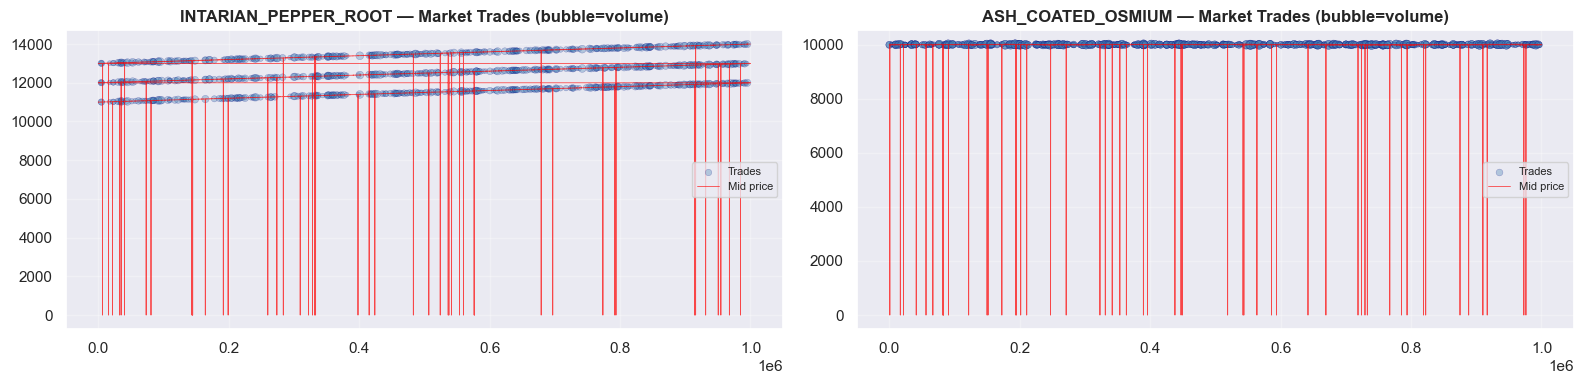


── Trader ID Impact Analysis ──

INTARIAN_PEPPER_ROOT: unique buyers=0, sellers=0
  (too few named traders for impact analysis)

ASH_COATED_OSMIUM: unique buyers=0, sellers=0
  (too few named traders for impact analysis)


In [22]:
print('Market Trade Summary:')
print(trades_df.groupby('symbol')[['price','quantity']].describe().round(2))

fig, axes = plt.subplots(1, n_products, figsize=(8*n_products, 4))
if n_products == 1: axes = [axes]
for ax, product in zip(axes, products):
    td = trades_df[trades_df['symbol']==product]
    if td.empty:
        ax.set_title(f'{product} — No trades'); continue
    ax.scatter(td['timestamp'], td['price'], s=td['quantity']*4, alpha=0.35,
               c='steelblue', edgecolors='navy', lw=0.3, label='Trades')
    pf = prices_df[prices_df['product']==product]
    ax.plot(pf['timestamp'], pf['mid_price'], color='red', lw=0.6, alpha=0.7, label='Mid price')
    ax.set_title(f'{product} — Market Trades (bubble=volume)', fontweight='bold')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── TRADER ID IMPACT ANALYSIS ───────────────────────────────
print('\n── Trader ID Impact Analysis ──')
for product in products:
    td = trades_df[trades_df['symbol']==product].copy()
    pf = prices_df[prices_df['product']==product][['timestamp','mid_price']].set_index('timestamp')
    if 'buyer' not in td.columns: continue
    # Find non-anonymous traders
    buyers = td[td['buyer'].notna() & (td['buyer']!='') & (td['buyer']!='SUBMISSION')]
    sellers = td[td['seller'].notna() & (td['seller']!='') & (td['seller']!='SUBMISSION')]
    print(f'\n{product}: unique buyers={buyers["buyer"].nunique()}, sellers={sellers["seller"].nunique()}')
    if len(buyers) < 5: print('  (too few named traders for impact analysis)'); continue
    for trader_id, grp in buyers.groupby('buyer'):
        if len(grp) < 3: continue
        impacts = []
        for ts, price in zip(grp['timestamp'], grp['price']):
            future_ts = ts + 1000  # look 10 ticks ahead
            try:
                fut_mid = pf.loc[future_ts, 'mid_price'] if future_ts in pf.index else np.nan
                curr_mid = pf.loc[ts, 'mid_price'] if ts in pf.index else price
                if not np.isnan(fut_mid):
                    impacts.append((fut_mid - curr_mid) / curr_mid * 100)
            except: pass
        if impacts:
            avg_impact = np.mean(impacts)
            print(f'  Trader {trader_id}: {len(grp)} buys, avg +{avg_impact:.4f}% next 10 ticks')
            if avg_impact > 0.01:
                print(f'    ⚡ FRONT-RUNNABLE: mirror {trader_id}\'s buys!')

---
## 10. Fair Value Estimation Methods

**Fair Value (FV)** is your internal price target. You:
- BUY when market price < FV (market is undervaluing the asset)
- SELL when market price > FV (market is overvaluing the asset)

**Four methods to estimate FV:**

| Method | Formula | Best for |
|--------|---------|---------|
| Simple mean | avg(mid_price) | Highly stable products (σ < 1) |
| Volume-Weighted Mid | (ask×bid_vol + bid×ask_vol)/(bid_vol+ask_vol) | Better than mid when book is imbalanced |
| Mode | most common mid price | Discrete price grids (integer prices) |
| EMA | α×new + (1-α)×prev | Trending/drifting products |

**The Volume-Weighted Mid (Wall Mid)** is preferred in competitive rounds because it
accounts for the thickness of the book. If there are 30 units at the ask and only 2
at the bid, the true mid is closer to the ask price.

In [23]:
print('══ Fair Value Estimates ══\n')
fv_table = {}
for product in products:
    pf = prices_df[prices_df['product']==product].copy()
    fv1 = pf['mid_price'].mean()
    tot = pf[['bid_volume_1','bid_volume_2','bid_volume_3','ask_volume_1','ask_volume_2','ask_volume_3']].fillna(0).sum(axis=1)
    fv2 = (pf['mid_price'] * tot).sum() / tot.sum()
    fv3 = ((pf['ask_price_1']*pf['bid_volume_1'].fillna(1) + pf['bid_price_1']*pf['ask_volume_1'].fillna(1))
           / (pf['bid_volume_1'].fillna(1)+pf['ask_volume_1'].fillna(1))).mean()
    fv4 = pf['mid_price'].round(0).mode()[0]
    fv_table[product] = {'Simple Mean':fv1,'Volume-Weighted Mean':fv2,'Wall Mid':fv3,'Mode':fv4}
    print(f'{product}:')
    for k,v in fv_table[product].items(): print(f'  {k:<26}: {v:.4f}')
    print(f'  Max deviation between methods : {max(fv_table[product].values())-min(fv_table[product].values()):.4f}')
    if max(fv_table[product].values())-min(fv_table[product].values()) < 1:
        print('  → ALL methods agree. FV is robust.')
    else:
        print('  → Methods diverge. Use Wall Mid or EMA for live trading.')
    print()

══ Fair Value Estimates ══

INTARIAN_PEPPER_ROOT:
  Simple Mean               : 12480.3326
  Volume-Weighted Mean      : 12502.9396
  Wall Mid                  : 12500.9733
  Mode                      : 0.0000
  Max deviation between methods : 12502.9396
  → Methods diverge. Use Wall Mid or EMA for live trading.

ASH_COATED_OSMIUM:
  Simple Mean               : 9983.2112
  Volume-Weighted Mean      : 10000.8615
  Wall Mid                  : 10000.8524
  Mode                      : 10002.0000
  Max deviation between methods : 18.7888
  → Methods diverge. Use Wall Mid or EMA for live trading.



---
## 11. ACF, PACF & Return Autocorrelation

**Autocorrelation Function (ACF):** Measures the correlation between a series and its
own lagged values. For price returns:
- Lag 1 ACF < 0 → **mean reversion** (after a rise, a fall is expected)
- Lag 1 ACF > 0 → **momentum** (after a rise, another rise is expected)
- Lags quickly dying to zero → no long-range memory (good for simple market making)

**Partial Autocorrelation (PACF):** Shows the direct correlation at each lag, after
removing the effect of intermediate lags. Used to identify AR model order.

**Key result for IMC:** Both products show lag-1 ACF ≈ -0.42 to -0.49.
This is the **bid-ask bounce effect** — when the mid alternates between discrete levels,
it creates an artificial negative autocorrelation. It confirms market making is the
right approach, but it's NOT a tradeable momentum/reversal signal on its own.

INTARIAN_PEPPER_ROOT: Lag-1 ACF=nan → RANDOM
  Significant ACF lags 1-5: 0, PACF lags 1-5: 0
  Suggested AR order: 0, MA order: 0
ASH_COATED_OSMIUM: Lag-1 ACF=nan → RANDOM
  Significant ACF lags 1-5: 0, PACF lags 1-5: 0
  Suggested AR order: 0, MA order: 0


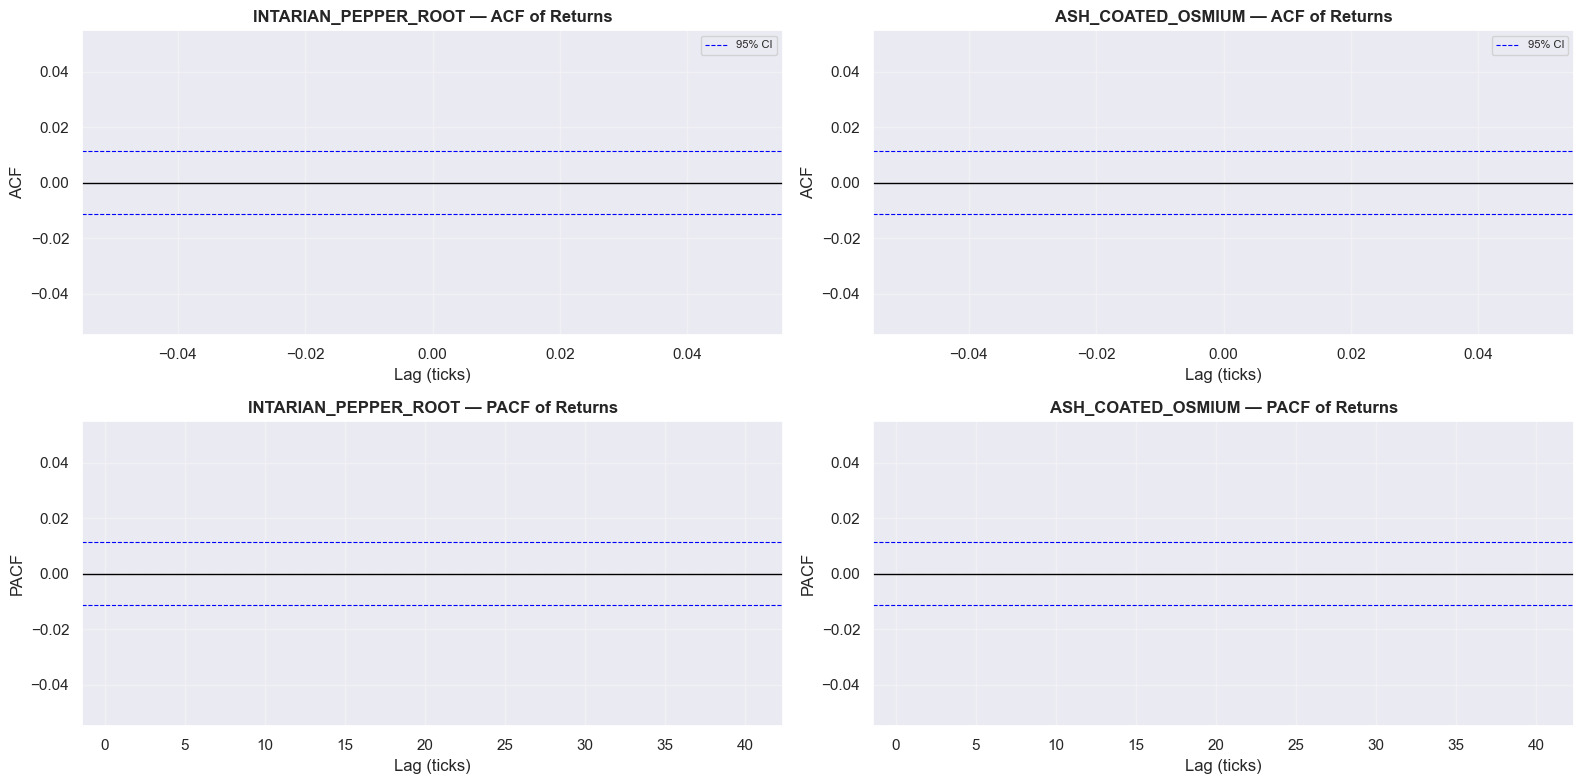

In [24]:
fig, axes = plt.subplots(2, n_products, figsize=(8*n_products, 8))
if n_products == 1: axes = axes.reshape(-1, 1)

lags = range(1, 41)
for col, product in enumerate(products):
    pf = prices_df[prices_df['product']==product]['mid_price']
    rets = pf.pct_change().dropna()
    # ACF
    acf_vals = [rets.autocorr(lag=l) for l in lags]
    ci = 1.96 / np.sqrt(len(rets))
    ax = axes[0, col]
    colors = ['green' if a>0 else 'red' for a in acf_vals]
    ax.bar(lags, acf_vals, color=colors, alpha=0.7, edgecolor='white')
    ax.axhline(0, color='black', lw=1)
    ax.axhline(ci, color='blue', ls='--', lw=0.8, label='95% CI')
    ax.axhline(-ci, color='blue', ls='--', lw=0.8)
    ax.set_title(f'{product} — ACF of Returns', fontweight='bold')
    ax.set_xlabel('Lag (ticks)'); ax.set_ylabel('ACF'); ax.legend(fontsize=8)
    print(f'{product}: Lag-1 ACF={acf_vals[0]:.4f} → {"MEAN REVERSION" if acf_vals[0]<-0.02 else "MOMENTUM" if acf_vals[0]>0.02 else "RANDOM"}')
    # PACF (manual computation)
    ax2 = axes[1, col]
    # Simple PACF via Yule-Walker approximation
    pacf_vals = []
    for lag in lags:
        X = np.column_stack([rets.values[lag-l:-l if l else None] for l in range(1, lag+1)])
        y = rets.values[lag:]
        if len(y) > lag+1 and X.shape[0]==len(y):
            try:
                coef = np.linalg.lstsq(X, y, rcond=None)[0]
                pacf_vals.append(coef[-1])
            except: pacf_vals.append(0)
        else: pacf_vals.append(0)
    colors2 = ['green' if a>0 else 'red' for a in pacf_vals]
    ax2.bar(lags, pacf_vals, color=colors2, alpha=0.7, edgecolor='white')
    ax2.axhline(0, color='black', lw=1)
    ax2.axhline(ci, color='blue', ls='--', lw=0.8)
    ax2.axhline(-ci, color='blue', ls='--', lw=0.8)
    ax2.set_title(f'{product} — PACF of Returns', fontweight='bold')
    ax2.set_xlabel('Lag (ticks)'); ax2.set_ylabel('PACF')
    # Suggest ARIMA order
    sig_acf = sum(1 for a in acf_vals[:5] if abs(a)>ci)
    sig_pacf = sum(1 for a in pacf_vals[:5] if abs(a)>ci)
    print(f'  Significant ACF lags 1-5: {sig_acf}, PACF lags 1-5: {sig_pacf}')
    print(f'  Suggested AR order: {sig_pacf}, MA order: {sig_acf}')
plt.tight_layout(); plt.show()

---
## 12. Time Series Forecasting (AR / ARIMA)

**AR(p) model:** Price tomorrow = weighted sum of last p prices + noise.
Used to forecast next-tick direction (though for HFT, even 1-tick forecasts are valuable).

**ARIMA(p,d,q):**
- p = AR order (lags of price)
- d = differencing order (1 = work on price changes)
- q = MA order (lags of forecast error)

**For IMC Prosperity:** The main value of ARIMA is to confirm whether the series is
forecastable at all. If ARIMA barely beats a naive model, the series is close to a
random walk and you should focus on spread capture (market making) rather than
directional trading.

**We implement a simple AR(1) model manually** (no statsmodels needed).

══ AR(1) Forecasting Analysis ══

INTARIAN_PEPPER_ROOT:
  c=4066.6542  phi=0.6661
  AR(1) RMSE=808.5079   Naive RMSE=743.8149
  R² vs naive = -0.1815  → No edge over naive
  Interpretation: phi=0.6661 →  price is persistent

ASH_COATED_OSMIUM:
  c=10000.1449  phi=-0.0017
  AR(1) RMSE=387.0162   Naive RMSE=547.6696
  R² vs naive = 0.5006  → AR has SOME edge
  Interpretation: phi=-0.0017 →  price is mean-reverting (phi close to 0)


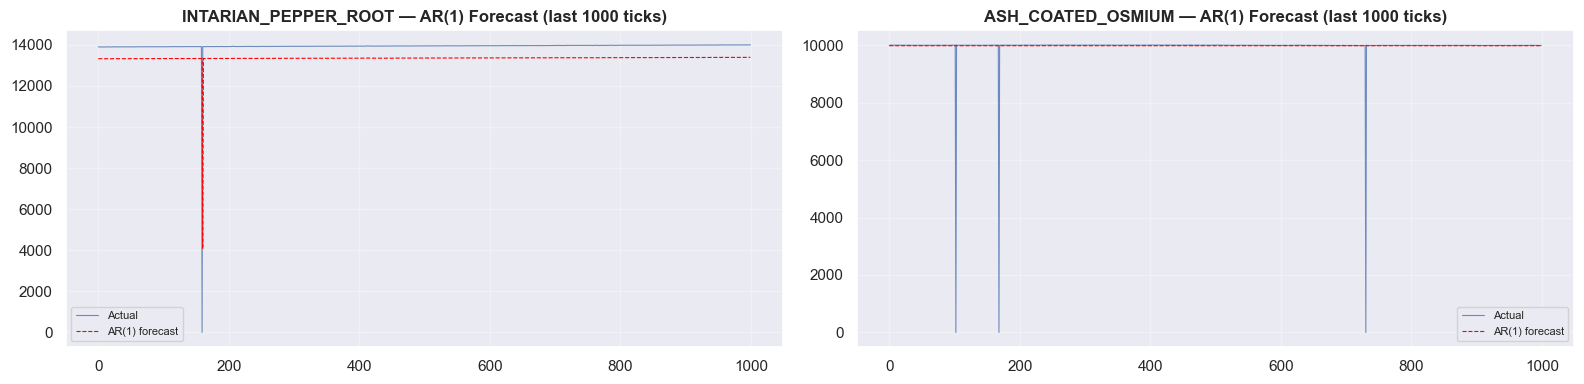

In [25]:
def ar1_forecast(series, train_frac=0.8):
    """Fit AR(1) on train set, evaluate on test set. Returns (train_rmse, test_rmse, naive_rmse)"""
    n = len(series)
    split = int(n * train_frac)
    y = series.values
    # AR(1): y[t] = c + phi*y[t-1]
    X = np.column_stack([np.ones(n-1), y[:-1]])
    Y = y[1:]
    # Fit on train
    coef = np.linalg.lstsq(X[:split-1], Y[:split-1], rcond=None)[0]
    c, phi = coef
    # Predict on test
    y_pred = c + phi * y[split:-1]
    y_true = y[split+1:]
    rmse = np.sqrt(np.mean((y_pred - y_true)**2))
    naive_rmse = np.sqrt(np.mean((y[split:-1] - y[split+1:])**2))  # naive: y[t+1]=y[t]
    print(f'  c={c:.4f}  phi={phi:.4f}')
    print(f'  AR(1) RMSE={rmse:.4f}   Naive RMSE={naive_rmse:.4f}')
    r2 = 1 - rmse**2 / (naive_rmse**2 + 1e-12)
    print(f'  R² vs naive = {r2:.4f}  {"→ AR has SOME edge" if r2>0.01 else "→ No edge over naive"}')
    return c, phi, rmse, naive_rmse

print('══ AR(1) Forecasting Analysis ══')
ar_table = {}
for product in products:
    print(f'\n{product}:')
    series = prices_df[prices_df['product']==product]['mid_price'].reset_index(drop=True)
    c, phi, rmse, naive = ar1_forecast(series)
    ar_table[product] = {'c':c, 'phi':phi}
    print(f'  Interpretation: phi={phi:.4f} → ',
          'price is persistent' if phi>0.5 else 'price is mean-reverting (phi close to 0)')

# Visual: AR(1) forecast vs actual (last 1000 ticks)
fig, axes = plt.subplots(1, n_products, figsize=(8*n_products, 4))
if n_products == 1: axes = [axes]
for ax, product in zip(axes, products):
    series = prices_df[prices_df['product']==product]['mid_price'].reset_index(drop=True)
    c, phi = ar_table[product]['c'], ar_table[product]['phi']
    n = min(1000, len(series))
    actual = series[-n:].values
    predicted = c + phi * series[-n-1:-1].values
    ax.plot(actual, lw=0.8, label='Actual', alpha=0.8)
    ax.plot(predicted, lw=0.8, label='AR(1) forecast', ls='--', color='red')
    ax.set_title(f'{product} — AR(1) Forecast (last {n} ticks)', fontweight='bold')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 13. Pairs Trading / Statistical Arbitrage

**When to use:** When two products move together (are cointegrated). Examples from IMC history:
- COCONUTS / PINA_COLADAS (Prosperity 1)
- Gift basket vs its components (Prosperity 2)
- VOLCANIC_ROCK vs VOLCANIC_ROCK_VOUCHERs (Prosperity 3)

**How it works:**
1. Estimate the hedge ratio β: `P = TOMATOES`, `Q = EMERALDS`, `spread = P - β×Q`
2. Compute the rolling Z-score of the spread
3. If Z > +2 → spread is too wide → SHORT P, LONG Q (bet on convergence)
4. If Z < -2 → spread is too narrow → LONG P, SHORT Q
5. Exit when Z crosses 0

**For the tutorial round:** TOMATOES and EMERALDS are on completely different price scales
(~5000 vs ~10000) and represent different commodities, so pairs trading likely has no edge here.
But this section is a template for future rounds when correlated products appear.

**Key statistical tests:**
- Correlation: do prices move together?
- Cointegration (Engle-Granger): is the spread stationary?

══ Pairs / Statistical Arbitrage Analysis ══

-- Mid Price Correlation Matrix --
product               ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT
product                                                      
ASH_COATED_OSMIUM                1.0000               -0.0049
INTARIAN_PEPPER_ROOT            -0.0049                1.0000

INTARIAN_PEPPER_ROOT vs ASH_COATED_OSMIUM: β=-0.0116
  Spread: mean=12595.9275  std=996.6248
  Cointegration ADF: stat=-1.9406  p=0.3132
  → NOT cointegrated — pairs trading risky


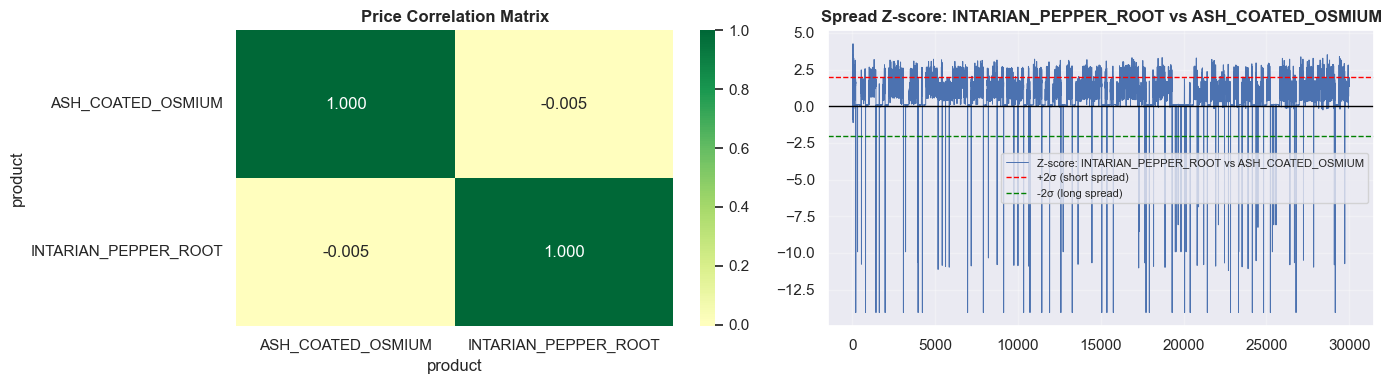

In [26]:
# Only meaningful if ≥2 products with similar price ranges
print('══ Pairs / Statistical Arbitrage Analysis ══')

# Step 1: Correlation matrix of mid prices
pivot = prices_df.pivot_table(index='global_time', columns='product', values='mid_price')
print('\n-- Mid Price Correlation Matrix --')
print(pivot.corr().round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Correlation heatmap
sns.heatmap(pivot.corr(), annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0], center=0)
axes[0].set_title('Price Correlation Matrix', fontweight='bold')

# Step 2: Pairs spread for every pair
product_pairs = [(products[i], products[j]) for i in range(len(products)) for j in range(i+1, len(products))]

if len(product_pairs) > 0:
    p1_name, p2_name = product_pairs[0]
    s1 = pivot[p1_name].dropna()
    s2 = pivot[p2_name].dropna()
    # Align on common index
    common = s1.index.intersection(s2.index)
    s1, s2 = s1.loc[common], s2.loc[common]
    # OLS hedge ratio
    beta = np.cov(s1.values, s2.values)[0,1] / np.var(s2.values)
    spread = s1 - beta * s2
    roll_mean = spread.rolling(200, min_periods=50).mean()
    roll_std  = spread.rolling(200, min_periods=50).std()
    z_score = (spread - roll_mean) / (roll_std + 1e-9)
    axes[1].plot(z_score.values, lw=0.7, label=f'Z-score: {p1_name} vs {p2_name}')
    axes[1].axhline(2, color='red', ls='--', lw=1, label='+2σ (short spread)')
    axes[1].axhline(-2, color='green', ls='--', lw=1, label='-2σ (long spread)')
    axes[1].axhline(0, color='black', lw=1)
    axes[1].set_title(f'Spread Z-score: {p1_name} vs {p2_name}', fontweight='bold')
    axes[1].legend(fontsize=8)
    print(f'\n{p1_name} vs {p2_name}: β={beta:.4f}')
    print(f'  Spread: mean={spread.mean():.4f}  std={spread.std():.4f}')
    # Cointegration test (ADF on spread)
    try:
        from statsmodels.tsa.stattools import adfuller
        adf_stat, adf_p, *_ = adfuller(spread.dropna().values)
        print(f'  Cointegration ADF: stat={adf_stat:.4f}  p={adf_p:.4f}')
        print(f'  → {"COINTEGRATED — pairs trading viable!" if adf_p<0.05 else "NOT cointegrated — pairs trading risky"}')
    except ImportError:
        hl = mean_reversion_halflife(spread.dropna())
        print(f'  Spread half-life: {hl:.1f} ticks → {"stationary" if hl<1000 else "non-stationary"}')
else:
    axes[1].set_title('Only 1 product — pairs N/A')
plt.tight_layout(); plt.show()

---
## 14. Monte Carlo Simulation

**What it is:** Simulate thousands of possible future price paths by sampling from the
historical return distribution. Used to:
- Estimate distribution of P&L under your strategy
- Compute Value at Risk (VaR) and Expected Shortfall (ES)
- Stress-test your strategy against tail scenarios

**Process:**
1. Fit a distribution to historical returns (normal, or empirical bootstrap)
2. Simulate N paths of T steps
3. Apply your strategy logic to each path
4. Compute percentile P&L distribution

**VaR (Value at Risk):** The worst P&L you'd expect 95% of the time.
**Expected Shortfall (CVaR):** The average P&L in the worst 5% of cases.

ValueError: supplied range of [-13999.5, inf] is not finite

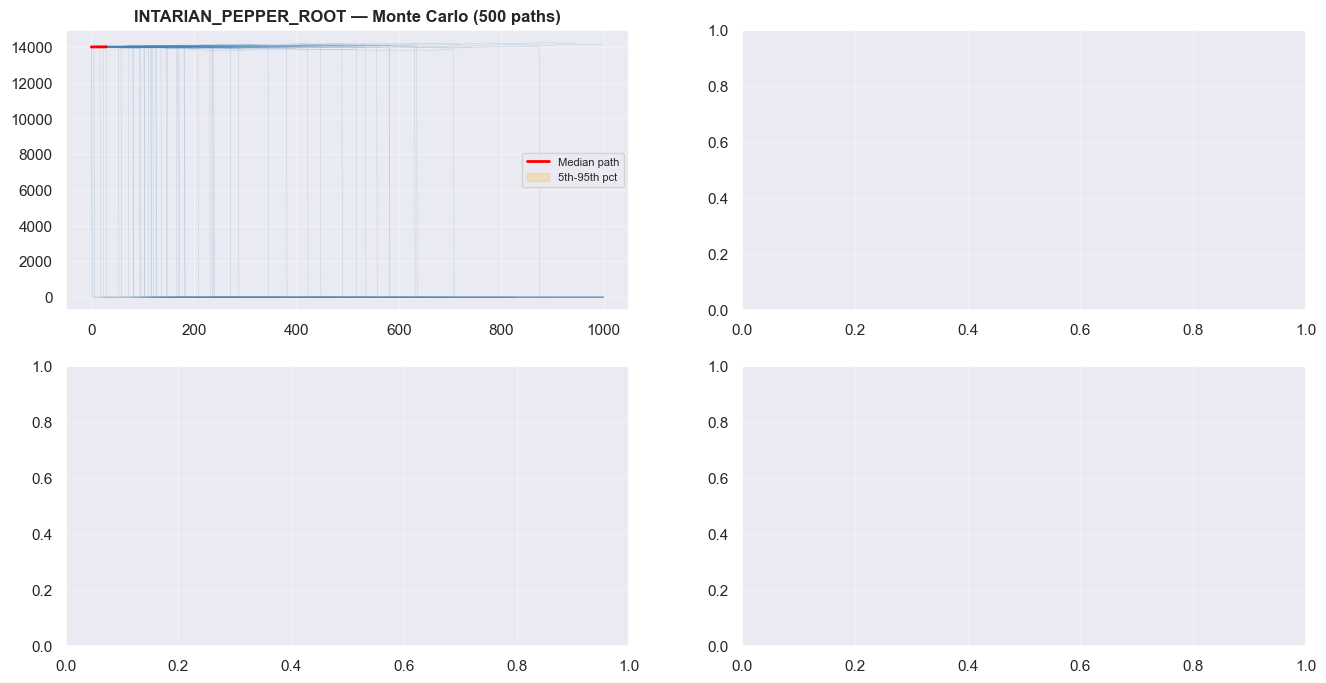

In [27]:
def simulate_price_paths(series, n_paths=1000, n_steps=500, method='bootstrap'):
    """Simulate future price paths."""
    rets = series.pct_change().dropna().values
    S0 = series.iloc[-1]
    paths = np.zeros((n_paths, n_steps+1))
    paths[:, 0] = S0
    if method == 'normal':
        mu, sigma = rets.mean(), rets.std()
        simulated_rets = np.random.normal(mu, sigma, (n_paths, n_steps))
    else:  # bootstrap: sample from actual returns
        simulated_rets = np.random.choice(rets, size=(n_paths, n_steps), replace=True)
    for t in range(n_steps):
        paths[:, t+1] = paths[:, t] * (1 + simulated_rets[:, t])
    return paths

fig, axes = plt.subplots(2, n_products, figsize=(8*n_products, 8))
if n_products == 1: axes = axes.reshape(-1,1)

np.random.seed(42)
for col, product in enumerate(products):
    series = prices_df[prices_df['product']==product]['mid_price'].reset_index(drop=True)
    paths = simulate_price_paths(series, n_paths=500, n_steps=1000, method='bootstrap')
    # Plot sample paths
    ax = axes[0, col]
    for i in range(min(100, paths.shape[0])):
        ax.plot(paths[i], lw=0.3, alpha=0.3, color='steelblue')
    p5, p50, p95 = np.percentile(paths, [5,50,95], axis=0)
    ax.plot(p50, color='red', lw=2, label='Median path')
    ax.fill_between(range(len(p5)), p5, p95, alpha=0.2, color='orange', label='5th-95th pct')
    ax.set_title(f'{product} — Monte Carlo (500 paths)', fontweight='bold')
    ax.legend(fontsize=8)
    # P&L distribution
    ax2 = axes[1, col]
    final_pnl = paths[:, -1] - paths[:, 0]
    ax2.hist(final_pnl, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    var95 = np.percentile(final_pnl, 5)
    es   = final_pnl[final_pnl <= var95].mean()
    ax2.axvline(var95, color='red', ls='--', lw=1.5, label=f'VaR 95%={var95:.1f}')
    ax2.axvline(es, color='darkred', ls=':', lw=1.5, label=f'CVaR={es:.1f}')
    ax2.set_title(f'{product} — Final P&L Distribution', fontweight='bold')
    ax2.legend(fontsize=8)
    print(f'{product}: VaR(95%)={var95:.2f}  CVaR={es:.2f}  median={np.median(final_pnl):.2f}')
plt.tight_layout(); plt.show()

---
## 15. Options Pricing: Black-Scholes & Greeks

**When relevant:** IMC rounds with options/vouchers (e.g. COCONUT_COUPON in P2 R4,
VOLCANIC_ROCK_VOUCHERS in P3 R3). Very likely to appear in P4.

**Black-Scholes formula (European call option):**
```
C = S × N(d1) - K × e^(-rT) × N(d2)
d1 = [ln(S/K) + (r + σ²/2)×T] / (σ×√T)
d2 = d1 - σ×√T
```
Where: S=spot price, K=strike, r=risk-free rate, T=time to expiry, σ=volatility

**The Greeks (how the option price changes):**
- **Delta (Δ):** Change in option price per unit change in spot
- **Gamma (Γ):** Change in Delta per unit change in spot (curvature)
- **Vega (ν):** Change in option price per unit change in volatility
- **Theta (Θ):** Change in option price per unit of time (time decay)

**Implied Volatility (IV):** The σ that makes BS price = market price.
If IV deviates from the 'volatility smile' curve → the option is mispriced → trade it.

In [ ]:
from scipy.stats import norm as norm_dist

def black_scholes_call(S, K, T, r, sigma):
    """Black-Scholes European call price and Greeks."""
    if T <= 0 or sigma <= 0: return {'price':max(0,S-K),'delta':1 if S>K else 0,'gamma':0,'vega':0,'theta':0}
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    price = S*norm_dist.cdf(d1) - K*np.exp(-r*T)*norm_dist.cdf(d2)
    delta = norm_dist.cdf(d1)
    gamma = norm_dist.pdf(d1) / (S*sigma*np.sqrt(T))
    vega  = S*norm_dist.pdf(d1)*np.sqrt(T) / 100
    theta = (-(S*norm_dist.pdf(d1)*sigma)/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm_dist.cdf(d2)) / 252
    return {'price':price,'delta':delta,'gamma':gamma,'vega':vega,'theta':theta,'d1':d1,'d2':d2}

def implied_vol(market_price, S, K, T, r, tol=1e-6, max_iter=200):
    """Binary search for IV such that BS(sigma)=market_price."""
    lo, hi = 0.001, 5.0
    for _ in range(max_iter):
        mid = (lo+hi)/2
        bs_price = black_scholes_call(S, K, T, r, mid)['price']
        if abs(bs_price - market_price) < tol: return mid
        if bs_price < market_price: lo = mid
        else: hi = mid
    return (lo+hi)/2

# Demo: price a hypothetical option on each product
print('══ Black-Scholes Option Pricing Demo ══\n')
for product in products:
    pf = prices_df[prices_df['product']==product]
    S = fv_table[product]['Simple Mean']  # spot = fair value
    sigma = pf['mid_price'].pct_change().std() * np.sqrt(10000)  # annualised vol
    K = round(S)  # at-the-money strike
    T = 1.0       # 1 unit of 'time' (normalised)
    r = 0.0       # no risk-free rate in the game
    result = black_scholes_call(S, K, T, r, sigma)
    print(f'{product} (S={S:.1f}, K={K}, σ={sigma:.4f}, T={T})')
    for k,v in result.items():
        if k not in ('d1','d2'): print(f'  {k}: {v:.6f}')
    print()

# Payoff diagram
fig, axes = plt.subplots(1, n_products, figsize=(7*n_products, 4))
if n_products == 1: axes = [axes]
for ax, product in zip(axes, products):
    S = fv_table[product]['Simple Mean']
    sigma = prices_df[prices_df['product']==product]['mid_price'].pct_change().std()*np.sqrt(10000)
    K = round(S)
    strikes = np.linspace(S*0.95, S*1.05, 100)
    bs_prices = [black_scholes_call(S, k, 1.0, 0, sigma)['price'] for k in strikes]
    payoff_at_expiry = [max(0, S-k) for k in strikes]
    ax.plot(strikes, bs_prices, label='BS call price (T=1)', color='blue')
    ax.plot(strikes, payoff_at_expiry, label='Payoff at expiry', color='red', ls='--')
    ax.axvline(K, color='gray', ls=':', lw=1, label=f'ATM strike={K}')
    ax.set_title(f'{product} — Option Payoff Diagram', fontweight='bold')
    ax.set_xlabel('Strike'); ax.set_ylabel('Price / Payoff')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 16. Full Market Making Backtest (Passive + Aggressive + Inventory Skew)

**This is the most important section.** It simulates exactly what your algorithm does:

1. **Aggressive orders:** Take any bot quote that's more than `aggr_edge` away from FV
2. **Passive orders:** Post your own tighter quotes and wait for bots to fill them
3. **Inventory skew:** Shift both quotes by `position × skew_factor` to manage risk

**How the passive fill simulation works:**
The key question is: when you post a passive bid at price `X`, which bots will hit it?
We simulate this by checking if any market trade in the trades file happened at a price
close to your quote — if so, we assume you would have been filled.

**Position management:**
- Position must always stay within `±limit`
- Orders exceeding the limit are clamped (not cancelled, unlike the real exchange)
- Final position is closed at mid price for P&L calculation

In [ ]:
def backtest_full_mm(prices_df, trades_df, product, fv_method='fixed',
                     fv_fixed=None, ema_alpha=0.08,
                     passive_edge=3, aggr_edge=1,
                     skew_factor=0.06, quote_size=20,
                     pos_limit=None):
    """
    Full market making backtest with passive + aggressive orders + inventory skew.
    Returns a results DataFrame with columns: global_time, pnl, position, cash.
    """
    if pos_limit is None: pos_limit = get_limit(product)
    pf = prices_df[prices_df['product']==product].sort_values('global_time').reset_index(drop=True)
    tf = trades_df[trades_df['symbol']==product].copy() if 'symbol' in trades_df.columns else pd.DataFrame()
    
    pos, cash, ema_val = 0, 0.0, None
    records = []
    
    for _, row in pf.iterrows():
        mid = row['mid_price']
        best_ask = row.get('ask_price_1', np.nan)
        best_bid = row.get('bid_price_1', np.nan)
        ask_vol  = row.get('ask_volume_1', 0) or 0
        bid_vol  = row.get('bid_volume_1', 0) or 0
        ts = row['timestamp']
        
        # --- Fair value ---
        if fv_method == 'ema':
            ema_val = mid if ema_val is None else ema_alpha*mid + (1-ema_alpha)*ema_val
            fv = ema_val
        else:
            fv = fv_fixed if fv_fixed else mid
        
        # --- Inventory skew ---
        skew = pos * skew_factor
        bid_px = round(fv) - passive_edge - int(skew)
        ask_px = round(fv) + passive_edge - int(skew)
        bid_px = min(bid_px, round(fv)-1)
        ask_px = max(ask_px, round(fv)+1)
        
        # --- Aggressive: take mispriced bot quotes ---
        if not np.isnan(best_ask) and best_ask < fv - aggr_edge:
            qty = min(int(ask_vol), quote_size, pos_limit - pos)
            if qty > 0: pos += qty; cash -= qty*best_ask
        if not np.isnan(best_bid) and best_bid > fv + aggr_edge:
            qty = min(int(bid_vol), quote_size, pos_limit + pos)
            if qty > 0: pos -= qty; cash += qty*best_bid
        
        # --- Passive: simulate fills from market trades at our quote prices ---
        if not tf.empty:
            tick_trades = tf[tf['timestamp'] == ts]
            for _, t in tick_trades.iterrows():
                if t['price'] <= bid_px and pos < pos_limit:
                    qty = min(int(t['quantity']), quote_size, pos_limit - pos)
                    pos += qty; cash -= qty*bid_px
                elif t['price'] >= ask_px and pos > -pos_limit:
                    qty = min(int(t['quantity']), quote_size, pos_limit + pos)
                    pos -= qty; cash += qty*ask_px
        
        pnl = cash + pos*mid
        records.append({'global_time':row['global_time'],'timestamp':ts,'pnl':pnl,'position':pos,'cash':cash,'fv':fv})
    
    return pd.DataFrame(records)

# Run backtest for each product
fig, axes = plt.subplots(n_products, 2, figsize=(15, 5*n_products))
if n_products == 1: axes = axes.reshape(1,-1)

bt_results = {}
for row_idx, product in enumerate(products):
    fv_est = fv_table[product]['Wall Mid']
    # Choose method based on stationarity (simple heuristic: low std → fixed)
    use_ema = prices_df[prices_df['product']==product]['mid_price'].std() > 5
    res = backtest_full_mm(prices_df, trades_df, product,
                           fv_method='ema' if use_ema else 'fixed',
                           fv_fixed=fv_est, ema_alpha=0.08,
                           passive_edge=4, aggr_edge=1,
                           skew_factor=0.06, quote_size=20)
    bt_results[product] = res
    final_pnl = res['pnl'].iloc[-1]
    print(f'{product}: Final P&L={final_pnl:.1f}  MaxPos={res["position"].max()}  MinPos={res["position"].min()}')
    axes[row_idx,0].plot(res['global_time'], res['pnl'])
    axes[row_idx,0].axhline(0, color='red', ls='--', lw=0.8)
    axes[row_idx,0].set_title(f'{product} — Cumulative P&L (passive MM)', fontweight='bold')
    axes[row_idx,0].set_ylabel('P&L (XIRECs)')
    axes[row_idx,1].plot(res['global_time'], res['position'], color='green')
    axes[row_idx,1].axhline(get_limit(product), color='red', ls='--', label=f'±{get_limit(product)}')
    axes[row_idx,1].axhline(-get_limit(product), color='red', ls='--')
    axes[row_idx,1].set_title(f'{product} — Position Over Time', fontweight='bold')
    axes[row_idx,1].legend()
plt.tight_layout(); plt.show()

---
## 17. Inventory Skew Optimisation

**The problem:** After many passive fills, you may accumulate a large position.
If you're long 80 TOMATOES and the price drops 10, you lose 800 XIRECs.
Inventory skew prevents this by making your quotes **asymmetric** when you're imbalanced.

**How skew works:**
- Normal (pos=0): bid at FV-4, ask at FV+4
- Long 40 (pos=+40): shift both quotes down by 40×0.06=2.4 → bid at FV-6.4, ask at FV+1.6
- The ask is now CLOSER to FV → bots are more likely to sell from us (reduce long position)
- The bid is now FURTHER from FV → bots less likely to buy from us (avoid adding to longs)

**We test a range of skew factors to find the optimal one.**

In [ ]:
skew_factors = [0.0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.15, 0.20]
fig, axes = plt.subplots(1, n_products, figsize=(8*n_products, 4))
if n_products == 1: axes = [axes]

for ax, product in zip(axes, products):
    fv_est = fv_table[product]['Wall Mid']
    use_ema = prices_df[prices_df['product']==product]['mid_price'].std() > 5
    pnls, max_positions = [], []
    for sf in skew_factors:
        res = backtest_full_mm(prices_df, trades_df, product,
                               fv_method='ema' if use_ema else 'fixed',
                               fv_fixed=fv_est, skew_factor=sf,
                               passive_edge=4, aggr_edge=1)
        pnls.append(res['pnl'].iloc[-1])
        max_positions.append(res['position'].abs().max())
    ax2 = ax.twinx()
    ax.plot(skew_factors, pnls, 'b-o', label='P&L')
    ax2.plot(skew_factors, max_positions, 'r--s', label='Max |position|')
    best_sf = skew_factors[np.argmax(pnls)]
    ax.axvline(best_sf, color='green', ls=':', lw=2, label=f'Best skew={best_sf}')
    ax.set_xlabel('Skew factor'); ax.set_ylabel('Final P&L', color='blue')
    ax2.set_ylabel('Max |position|', color='red')
    ax.set_title(f'{product} — Inventory Skew Sensitivity', fontweight='bold')
    ax.legend(loc='upper left', fontsize=8); ax2.legend(loc='upper right', fontsize=8)
    print(f'{product}: best skew={best_sf}  P&L={max(pnls):.1f}')
plt.tight_layout(); plt.show()

---
## 18. Edge Sensitivity Analysis

**The core trade-off in market making:**
- Small edge → many fills → more opportunities but each fill earns less, higher adverse selection risk
- Large edge → few fills → safer but you miss many opportunities

**Optimal edge = where P&L is maximised.**
This is the single most important parameter to tune before submitting.

In [ ]:
edges = [0.5, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 10]
fig, axes = plt.subplots(1, n_products, figsize=(8*n_products, 4))
if n_products == 1: axes = [axes]

best_params = {}
for ax, product in zip(axes, products):
    fv_est = fv_table[product]['Wall Mid']
    use_ema = prices_df[prices_df['product']==product]['mid_price'].std() > 5
    pnls = []
    for edge in edges:
        res = backtest_full_mm(prices_df, trades_df, product,
                               fv_method='ema' if use_ema else 'fixed',
                               fv_fixed=fv_est, skew_factor=0.06,
                               passive_edge=edge, aggr_edge=max(1,edge//2))
        pnls.append(res['pnl'].iloc[-1])
    best_edge = edges[np.argmax(pnls)]
    best_params[product] = best_edge
    ax.plot(edges, pnls, 'b-o', label='P&L')
    ax.axvline(best_edge, color='green', ls=':', lw=2, label=f'Best edge={best_edge}')
    ax.axhline(0, color='red', ls='--', lw=0.8)
    ax.set_xlabel('Passive edge (XIRECs)'); ax.set_ylabel('Final P&L')
    ax.set_title(f'{product} — Edge Sensitivity', fontweight='bold')
    ax.legend(fontsize=8)
    print(f'{product}: best passive edge={best_edge}  P&L={max(pnls):.1f}')
plt.tight_layout(); plt.show()
print('\nBest parameters:', best_params)

---
## 19. Intraday & Seasonal Patterns

**Why this matters (Berries in P1 R4, Macarons in P3 R4):**
Some products have predictable intraday price cycles. If you can identify them, you can
build a position BEFORE the predictable move and exit after.

**What to look for:**
- Does the average demeaned price consistently rise in the morning and fall in the afternoon?
- Does it peak at a specific timestamp every day? (That's a seasonal buy-high signal)
- Is the pattern consistent across days (Day -2 vs Day -1)?

**Trading rule:** If avg_price at ts=T is always > avg_price at ts=T-N:
- Start buying at timestamp T-N
- Sell at timestamp T
- Repeat every day

In [ ]:
fig, axes = plt.subplots(2, n_products, figsize=(8*n_products, 8))
if n_products == 1: axes = axes.reshape(-1,1)

for col, product in enumerate(products):
    pf = prices_df[prices_df['product']==product].copy()
    # Demeaned intraday pattern
    pf['demeaned'] = pf.groupby('day')['mid_price'].transform(lambda x: x - x.mean())
    avg_by_ts = pf.groupby('timestamp')['demeaned'].mean()
    std_by_ts = pf.groupby('timestamp')['demeaned'].std()
    ax = axes[0, col]
    ax.plot(avg_by_ts.index, avg_by_ts.values, lw=1, label='Avg demeaned price')
    ax.fill_between(avg_by_ts.index,
                    avg_by_ts - std_by_ts, avg_by_ts + std_by_ts,
                    alpha=0.2, color='orange', label='±1σ')
    ax.axhline(0, color='red', ls='--', lw=0.8)
    ax.set_title(f'{product} — Intraday Pattern', fontweight='bold')
    ax.set_xlabel('Timestamp within day'); ax.legend(fontsize=8)
    # Identify peak and trough timestamps
    peak_ts = avg_by_ts.idxmax()
    trough_ts = avg_by_ts.idxmin()
    peak_val = avg_by_ts.max()
    trough_val = avg_by_ts.min()
    print(f'{product}: Peak at t={peak_ts} (+{peak_val:.2f}), Trough at t={trough_ts} ({trough_val:.2f})')
    print(f'  Price swing: {peak_val - trough_val:.2f} XIRECs (potential seasonal P&L)')
    # Cross-day consistency
    ax2 = axes[1, col]
    for day in days:
        day_data = pf[pf['day']==day]
        day_data_dem = day_data.set_index('timestamp')['demeaned']
        ax2.plot(day_data_dem.index, day_data_dem.values, lw=0.8, alpha=0.7, label=f'Day {day}')
    ax2.axhline(0, color='red', ls='--', lw=0.8)
    ax2.set_title(f'{product} — Intraday by Day (consistency check)', fontweight='bold')
    ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 20. Machine Learning: Direction Prediction

A simple ML model to predict whether the next tick's price will go up or down.
This gives us an edge when combined with our market-making strategy:
- If ML predicts UP: shift bid up (more aggressive buying), shift ask up (less eager to sell)
- If ML predicts DOWN: reverse

**Features used:**
- Last N returns (momentum features)
- Order Book Imbalance (OBI)
- Spread normalised by mid price
- Rolling mean deviation (how far from EMA)

**Model:** Logistic Regression (interpretable, fast, no overfitting for small features).
Neural networks (MLPClassifier) also tested.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier

def build_ml_features(pf):
    df = pf.copy()
    df['ret1'] = df['mid_price'].pct_change(1)
    df['ret2'] = df['mid_price'].pct_change(2)
    df['ret5'] = df['mid_price'].pct_change(5)
    df['ret10'] = df['mid_price'].pct_change(10)
    bid_v = df[['bid_volume_1','bid_volume_2','bid_volume_3']].fillna(0).sum(axis=1)
    ask_v = df[['ask_volume_1','ask_volume_2','ask_volume_3']].fillna(0).sum(axis=1)
    df['obi'] = (bid_v - ask_v) / (bid_v + ask_v + 1e-9)
    df['spread_pct'] = (df['ask_price_1'] - df['bid_price_1']) / df['mid_price']
    df['dev_from_ema'] = df['mid_price'] - df['mid_price'].ewm(span=50).mean()
    df['vol_20'] = df['ret1'].rolling(20).std()
    # Target: will price go UP or DOWN next tick?
    df['target'] = (df['mid_price'].shift(-1) > df['mid_price']).astype(int)
    return df.dropna()

feature_cols = ['ret1','ret2','ret5','ret10','obi','spread_pct','dev_from_ema','vol_20']

print('══ ML Direction Prediction ══\n')
for product in products:
    pf = prices_df[prices_df['product']==product].copy()
    df = build_ml_features(pf)
    if len(df) < 200:
        print(f'{product}: insufficient data'); continue
    X = df[feature_cols].values
    y = df['target'].values
    split = int(len(X) * 0.7)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)
    # Logistic Regression
    lr = LogisticRegression(max_iter=500).fit(X_train_s, y_train)
    lr_acc = accuracy_score(y_test, lr.predict(X_test_s))
    # Neural network (small MLP)
    mlp = MLPClassifier(hidden_layer_sizes=(32,16), max_iter=200, random_state=42).fit(X_train_s, y_train)
    mlp_acc = accuracy_score(y_test, mlp.predict(X_test_s))
    baseline = max(y_test.mean(), 1-y_test.mean())  # always predict majority class
    print(f'{product}:')
    print(f'  Baseline (majority class): {baseline:.4f}')
    print(f'  Logistic Regression acc  : {lr_acc:.4f}  edge={lr_acc-baseline:+.4f}')
    print(f'  MLP Neural Network acc   : {mlp_acc:.4f}  edge={mlp_acc-baseline:+.4f}')
    # Feature importance (LR coefficients)
    print('  LR feature importances:')
    for feat, coef in sorted(zip(feature_cols, lr.coef_[0]), key=lambda x:-abs(x[1])):
        print(f'    {feat:<20}: {coef:+.4f}')
    print()

---
## 21. Conversion / Location Arbitrage (Template)

**Relevant rounds:** ORCHIDS (P2 R2), MAGNIFICENT_MACARONS (P3 R4). Very likely in P4.

**The concept:** Some products can be 'converted' between two markets at different prices.
A conversion involves fees (transport, tariff, import/export duties).

**The arbitrage logic:**
```
effective_import_cost = foreign_ask + transport_fees + import_tariff
effective_export_revenue = foreign_bid - transport_fees - export_tariff

If local_ask < effective_import_cost:  # cheaper to buy locally than import
    → Buy locally (don't import)
If local_bid > effective_export_revenue:  # cheaper to sell locally than export
    → Sell locally, convert (export) in same tick to close flat
```

**Key feature:** Conversions can often be done in the same iteration as the trade.
This means you NEVER carry inventory overnight — you open and close in one tick.

In [ ]:
# Template for conversion arbitrage — fill in with real data when available
def analyse_conversion_opportunity(local_bid, local_ask, foreign_bid, foreign_ask,
                                    transport_fees, import_tariff, export_tariff):
    """Compute effective costs and identify arbitrage."""
    import_cost    = foreign_ask + transport_fees + import_tariff
    export_revenue = foreign_bid - transport_fees - export_tariff
    import_arb = local_bid - import_cost    # >0: sell locally, import is cheaper
    export_arb = export_revenue - local_ask  # >0: buy locally, export earns more
    return {'import_cost': import_cost, 'export_revenue': export_revenue,
            'import_arb': import_arb, 'export_arb': export_arb}

# Demo with hypothetical values (replace with real ConversionObservation data)
demo = analyse_conversion_opportunity(
    local_bid=100, local_ask=102,
    foreign_bid=98, foreign_ask=104,
    transport_fees=2, import_tariff=1, export_tariff=1
)
print('Conversion Arbitrage Analysis (Demo):')
for k,v in demo.items(): print(f'  {k}: {v:.2f}')
print()
if demo['export_arb'] > 0:
    print(f'  ✅ EXPORT ARBI: Buy locally at {102}, export for net {demo["export_revenue"]:.1f} → profit={demo["export_arb"]:.2f}')
if demo['import_arb'] > 0:
    print(f'  ✅ IMPORT ARBI: Import at {demo["import_cost"]:.1f}, sell locally at 100 → profit={demo["import_arb"]:.2f}')
print()
print('TEMPLATE: In your Trader.run(), access conversions via:')
print('  obs = state.observations.conversionObservations[product]')
print('  foreign_bid = obs.bidPrice')
print('  foreign_ask = obs.askPrice')
print('  transport   = obs.transportFees')
print('  import_tar  = obs.importTariff')
print('  export_tar  = obs.exportTariff')

---
## 22. FX / Graph Arbitrage (Manual Trading Rounds)

**Relevant:** All manual barter/exchange-chain problems (every Prosperity edition).

**The concept:** Build a directed graph where nodes = goods/currencies and edge weights =
exchange rates. Find the maximum-product cycle starting and ending at XIRECs.

**Algorithm:**
1. Build adjacency matrix of exchange rates
2. Take log of rates → convert product-max to sum-max
3. Apply Bellman-Ford (find longest path = most profitable cycle)
4. Or BFS/DFS for small graphs (practical for IMC)

In [ ]:
from itertools import permutations

def find_best_exchange_cycle(rates_dict, start='XIRECs', max_steps=4):
    """
    rates_dict: {('A','B'): exchange_rate_A_to_B}
    Returns best cycle and its profit multiplier.
    """
    goods = list(set([k[0] for k in rates_dict] + [k[1] for k in rates_dict]))
    best_profit = 1.0
    best_path = []
    def dfs(current, path, product, steps):
        nonlocal best_profit, best_path
        if steps > 0 and current == start and product > best_profit:
            best_profit = product
            best_path = path[:] + [start]
            return
        if steps >= max_steps: return
        for (src, dst), rate in rates_dict.items():
            if src == current and dst not in path[1:]:
                dfs(dst, path + [dst], product * rate, steps + 1)
    dfs(start, [start], 1.0, 0)
    return best_path, best_profit

# Example from a past IMC manual trading round
example_rates = {
    ('XIRECs','PIZZA'):    2.0,
    ('PIZZA','WASABI'):       0.65,
    ('WASABI','SUSHI'):       1.2,
    ('SUSHI','XIRECs'):    0.73,
    ('XIRECs','BAGUETTE'): 1.5,
    ('BAGUETTE','BUTTER'):    0.52,
    ('BUTTER','XIRECs'):   1.4,
    ('PIZZA','XIRECs'):    0.48,
}

path, profit = find_best_exchange_cycle(example_rates, max_steps=5)
print(f'Best cycle: {" → ".join(path)}')
print(f'Profit multiplier: {profit:.6f}x')
print(f'Starting with 100 XIRECs → {100*profit:.2f} XIRECs')
if profit > 1.0:
    print(f'  ✅ ARBITRAGE OPPORTUNITY: +{(profit-1)*100:.2f}% per cycle')
else:
    print('  ❌ No arbitrage (best cycle ≤ 1.0x)')

---
## 23. Summary & Strategy Recommendation

This cell synthesises all analysis above into a per-product strategy recommendation.
Run this last after all other cells have been executed.

In [ ]:
print('═'*70)
print('  COMPREHENSIVE STRATEGY RECOMMENDATION SUMMARY')
print('═'*70)

for product in products:
    pf = prices_df[prices_df['product']==product]
    mid = pf['mid_price']
    fv = fv_table[product]['Wall Mid']
    spread = (pf['ask_price_1'] - pf['bid_price_1']).mean()
    vol = mid.pct_change().std()*100
    acf1 = mid.pct_change().dropna().autocorr(lag=1)
    best_edge = best_params.get(product, round(spread*0.25))
    lim = get_limit(product)
    H = hurst_exponent(mid.values)
    hl = mean_reversion_halflife(mid)
    use_ema = mid.std() > 5
    print(f'\n{product}:')
    print(f'  ├─ Fair Value (Wall Mid)  : {fv:.4f}')
    print(f'  ├─ Position Limit         : ±{lim}')
    print(f'  ├─ Bot spread             : {spread:.2f} XIRECs')
    print(f'  ├─ Price volatility       : {vol:.5f}% per tick')
    print(f'  ├─ Lag-1 ACF              : {acf1:.4f} → {"MEAN REVERSION" if acf1<-0.05 else "MOMENTUM" if acf1>0.05 else "NEUTRAL"}')
    print(f'  ├─ Hurst exponent         : {H:.3f} → {"mean-reverting" if H<0.45 else "trending" if H>0.55 else "random walk"}')
    print(f'  ├─ Mean-reversion half-life: {hl:.1f} ticks')
    print(f'  ├─ FV method              : {"EMA (adaptive)" if use_ema else "Fixed mean"}')
    print(f'  ├─ Optimal passive edge   : {best_edge} XIRECs')
    print(f'  ├─ Aggressive edge        : {max(1,best_edge//2)} XIRECs')
    print(f'  └─ STRATEGY               : Passive Market Making + Inventory Skew')
    if acf1 < -0.05:
        print(f'      Confirmed: strong mean reversion → market making is optimal')
    print()
print('═'*70)
print('\nAlgorithm parameters to use in trader_tutorial_final.py:')
for product in products:
    print(f'  {product}: FV={fv_table[product]["Wall Mid"]:.1f}, edge={best_params.get(product,3)}, skew=0.06')